# HumAID Disaster Tweet Classification: BERT_Base Fine-Tuning Benchmark

This notebook implements an optimized, fast hyperparameter tuning and fine-tuning benchmark for **BERT_Base** (`bert-base-uncased`) on 10 humanitarian crisis categories:

1. **Stage 1: Fast Learning Rate & Sequence Length Sweep**
   - Evaluates learning rates $\eta \in \{1\text{e-}5, 2\text{e-}5, 3\text{e-}5, 5\text{e-}5\}$ and sequence length ($L=48, 64$).
   - Leverages **FP16 Automatic Mixed Precision (AMP)** and **Batch Size 32** for fast convergence (~1.5 min per trial).
   - Generates learning rate sensitivity curves and validation metric tracking.

2. **Stage 2: Full Fine-Tuning of Optimal Configuration**
   - Fine-tunes `bert-base-uncased` using the optimal $(\eta^*, L^*)$ configuration with Linear Warmup + Cosine Decay.
   - Evaluates on the unseen test set.

3. **Evaluation Artifacts Generated**
   - Dual confusion matrices (Counts and Normalized % with formatted human class names, 35° rotation, 300 DPI).
   - Per-class precision, recall, and F1-score bar charts.
   - Loss & Macro F1 convergence curves across epochs.
   - Serialized model checkpoint (`best_model.pt`) and classification reports (`.csv` and `.txt`).


In [1]:
import os
import gc
import re
import time
import glob
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Any

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Compute Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")


Using Compute Device: cuda
GPU Name: Tesla T4
Memory Allocated: 0.00 MB


In [2]:
# Robust Data Path Resolution
def find_data_file(filename):
    search_patterns = [
        f"/kaggle/input/**/{filename}",
        f"dataset/{filename}",
        f"d:/nlp-project/dataset/{filename}",
        f"../dataset/{filename}",
        f"**/{filename}"
    ]
    for pattern in search_patterns:
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]
    return None

train_file = find_data_file("train_clean.parquet") or find_data_file("train.parquet")
val_file = find_data_file("validation_clean.parquet") or find_data_file("validation.parquet")
test_file = find_data_file("test_clean.parquet") or find_data_file("test.parquet")

if train_file is None or val_file is None or test_file is None:
    print("[!] Parquet files not found locally, downloading from Google Drive...")
    import gdown
    os.makedirs("dataset", exist_ok=True)
    GDRIVE_URL = "https://drive.google.com/drive/folders/1pyMBc4SFc-sQvfmReiywPoN5cQbMpQBR?usp=drive_link"
    gdown.download_folder(url=GDRIVE_URL, output="dataset", quiet=False, use_cookies=False)
    train_file = find_data_file("train_clean.parquet") or find_data_file("train.parquet")
    val_file = find_data_file("validation_clean.parquet") or find_data_file("validation.parquet")
    test_file = find_data_file("test_clean.parquet") or find_data_file("test.parquet")

print(f"Found Train File: {train_file}")
print(f"Found Val File:   {val_file}")
print(f"Found Test File:  {test_file}")

# Output directory structure
OUTPUT_BASE = "results/05_transformer_bert"
if not os.path.exists("results") and os.path.exists("/kaggle/working"):
    OUTPUT_BASE = "/kaggle/working/results/05_transformer_bert"

MODEL_DIR = os.path.join(OUTPUT_BASE, "models", "bert_base")
TUNING_DIR = os.path.join(OUTPUT_BASE, "tuning")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(TUNING_DIR, exist_ok=True)
print(f"Output directory initialized at: {OUTPUT_BASE}")


Found Train File: /kaggle/input/datasets/nayeem898/humaid-disaster-tweets-parquet/train.parquet
Found Val File:   /kaggle/input/datasets/nayeem898/humaid-disaster-tweets-parquet/validation.parquet
Found Test File:  /kaggle/input/datasets/nayeem898/humaid-disaster-tweets-parquet/test.parquet
Output directory initialized at: /kaggle/working/results/05_transformer_bert


In [3]:
# Load datasets
train_df = pd.read_parquet(train_file)
val_df = pd.read_parquet(val_file)
test_df = pd.read_parquet(test_file)

text_col = 'clean_text' if 'clean_text' in train_df.columns else ('text' if 'text' in train_df.columns else train_df.columns[0])
label_col = 'label' if 'label' in train_df.columns else ('class_label' if 'class_label' in train_df.columns else train_df.columns[1])

print(f"Dataset Loaded:")
print(f"  Train:      {len(train_df):,} samples")
print(f"  Validation: {len(val_df):,} samples")
print(f"  Test:       {len(test_df):,} samples")

raw_labels = sorted(train_df[label_col].unique().tolist())
label2id = {lbl: i for i, lbl in enumerate(raw_labels)}
id2label = {i: lbl for lbl, i in label2id.items()}
num_classes = len(raw_labels)

def format_label(name):
    return ' '.join(word.capitalize() for word in str(name).replace('_', ' ').split())

formatted_class_names = [format_label(id2label[i]) for i in range(num_classes)]

train_texts = train_df[text_col].astype(str).tolist()
val_texts = val_df[text_col].astype(str).tolist()
test_texts = test_df[text_col].astype(str).tolist()

y_train = np.array([label2id[l] for l in train_df[label_col]], dtype=np.int64)
y_val = np.array([label2id[l] for l in val_df[label_col]], dtype=np.int64)
y_test = np.array([label2id[l] for l in test_df[label_col]], dtype=np.int64)

MODEL_HF_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_HF_NAME)
print(f"Loaded Tokenizer: {MODEL_HF_NAME} (Vocab Size: {len(tokenizer):,})")


Dataset Loaded:
  Train:      53,531 samples
  Validation: 7,793 samples
  Test:       15,160 samples


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded Tokenizer: bert-base-uncased (Vocab Size: 30,522)


In [4]:
class TransformerTweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

def get_dataloaders(max_len, batch_size=32):
    train_enc = tokenizer(train_texts, truncation=True, padding='max_length', max_length=max_len)
    val_enc = tokenizer(val_texts, truncation=True, padding='max_length', max_length=max_len)
    test_enc = tokenizer(test_texts, truncation=True, padding='max_length', max_length=max_len)
    
    train_ds = TransformerTweetDataset(train_enc, y_train)
    val_ds = TransformerTweetDataset(val_enc, y_val)
    test_ds = TransformerTweetDataset(test_enc, y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, pin_memory=True)
    
    return train_loader, val_loader, test_loader


In [5]:
# Fast Hyperparameter Sweep (Learning Rate & Sequence Length)
tuning_configs = [
    {"name": "lr_1e-5_L48", "lr": 1e-5, "max_len": 48, "epochs": 2},
    {"name": "lr_2e-5_L48", "lr": 2e-5, "max_len": 48, "epochs": 2},
    {"name": "lr_3e-5_L48", "lr": 3e-5, "max_len": 48, "epochs": 2},
    {"name": "lr_5e-5_L48", "lr": 5e-5, "max_len": 48, "epochs": 2},
    {"name": "lr_2e-5_L64", "lr": 2e-5, "max_len": 64, "epochs": 2},
]

print("="*75)
print(f"STAGE 1: BERT_Base Fast Hyperparameter Sweep (AMP FP16, Batch 32)")
print("="*75)

tuning_results = []
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

for cfg in tuning_configs:
    t0 = time.time()
    print(f"\n--> Evaluating Config: {cfg['name']} (LR={cfg['lr']}, MaxLen={cfg['max_len']})...")
    
    train_loader, val_loader, _ = get_dataloaders(max_len=cfg["max_len"], batch_size=32)
    set_seed(42)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_HF_NAME, num_labels=num_classes)
    model.to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=0.01)
    total_steps = len(train_loader) * cfg["epochs"]
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * 0.1), num_training_steps=total_steps)
    
    best_val_f1 = 0.0
    best_val_acc = 0.0
    
    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                    loss = outputs.loss
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
            scheduler.step()
            
        # Validation
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                if scaler:
                    with torch.cuda.amp.autocast():
                        logits = model(input_ids, attention_mask=attention_mask).logits
                else:
                    logits = model(input_ids, attention_mask=attention_mask).logits
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                targets.extend(batch['labels'].numpy())
                
        val_acc = accuracy_score(targets, preds)
        _, _, val_f1, _ = precision_recall_fscore_support(targets, preds, average='macro', zero_division=0)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            
    elapsed = time.time() - t0
    print(f"    Val Macro F1: {best_val_f1:.4f} | Val Accuracy: {best_val_acc:.4f} | Time: {elapsed:.1f}s")
    tuning_results.append({
        "Config": cfg["name"], "Learning_Rate": cfg["lr"], "Max_Len": cfg["max_len"],
        "Val_Macro_F1": round(best_val_f1, 4), "Val_Accuracy": round(best_val_acc, 4),
        "Time_Sec": round(elapsed, 1)
    })
    
    del model, optimizer, scheduler
    torch.cuda.empty_cache()
    gc.collect()

df_tune = pd.DataFrame(tuning_results).sort_values(by="Val_Macro_F1", ascending=False)
df_tune.to_csv(os.path.join(TUNING_DIR, "hyperparam_tuning_results.csv"), index=False)

print("\n" + "="*75)
print(f"STAGE 1 SUMMARY: BERT_Base Hyperparameter Ranking")
print("="*75)
print(df_tune.to_string(index=False))

best_cfg = df_tune.iloc[0]
BEST_LR = float(best_cfg["Learning_Rate"])
BEST_MAX_LEN = int(best_cfg["Max_Len"])
print(f"\n>> Optimal Configuration: Learning Rate = {BEST_LR}, Max Length = {BEST_MAX_LEN} (Val Macro F1 = {best_cfg['Val_Macro_F1']:.4f})")


STAGE 1: BERT_Base Fast Hyperparameter Sweep (AMP FP16, Batch 32)

--> Evaluating Config: lr_1e-5_L48 (LR=1e-05, MaxLen=48)...


/tmp/ipykernel_23/3405832315.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_23/3405832315.py:42: F

...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_23/3405832315.py:42: F

    Val Macro F1: 0.7585 | Val Accuracy: 0.7765 | Time: 382.7s

--> Evaluating Config: lr_2e-5_L64 (LR=2e-05, MaxLen=64)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_23/3405832315.py:42: F

    Val Macro F1: 0.7545 | Val Accuracy: 0.7775 | Time: 461.8s

STAGE 1 SUMMARY: BERT_Base Hyperparameter Ranking
     Config  Learning_Rate  Max_Len  Val_Macro_F1  Val_Accuracy  Time_Sec
lr_3e-5_L48        0.00003       48        0.7600        0.7784     382.6
lr_5e-5_L48        0.00005       48        0.7585        0.7765     382.7
lr_2e-5_L48        0.00002       48        0.7581        0.7763     381.4
lr_2e-5_L64        0.00002       64        0.7545        0.7775     461.8
lr_1e-5_L48        0.00001       48        0.7520        0.7729     387.2

>> Optimal Configuration: Learning Rate = 3e-05, Max Length = 48 (Val Macro F1 = 0.7600)


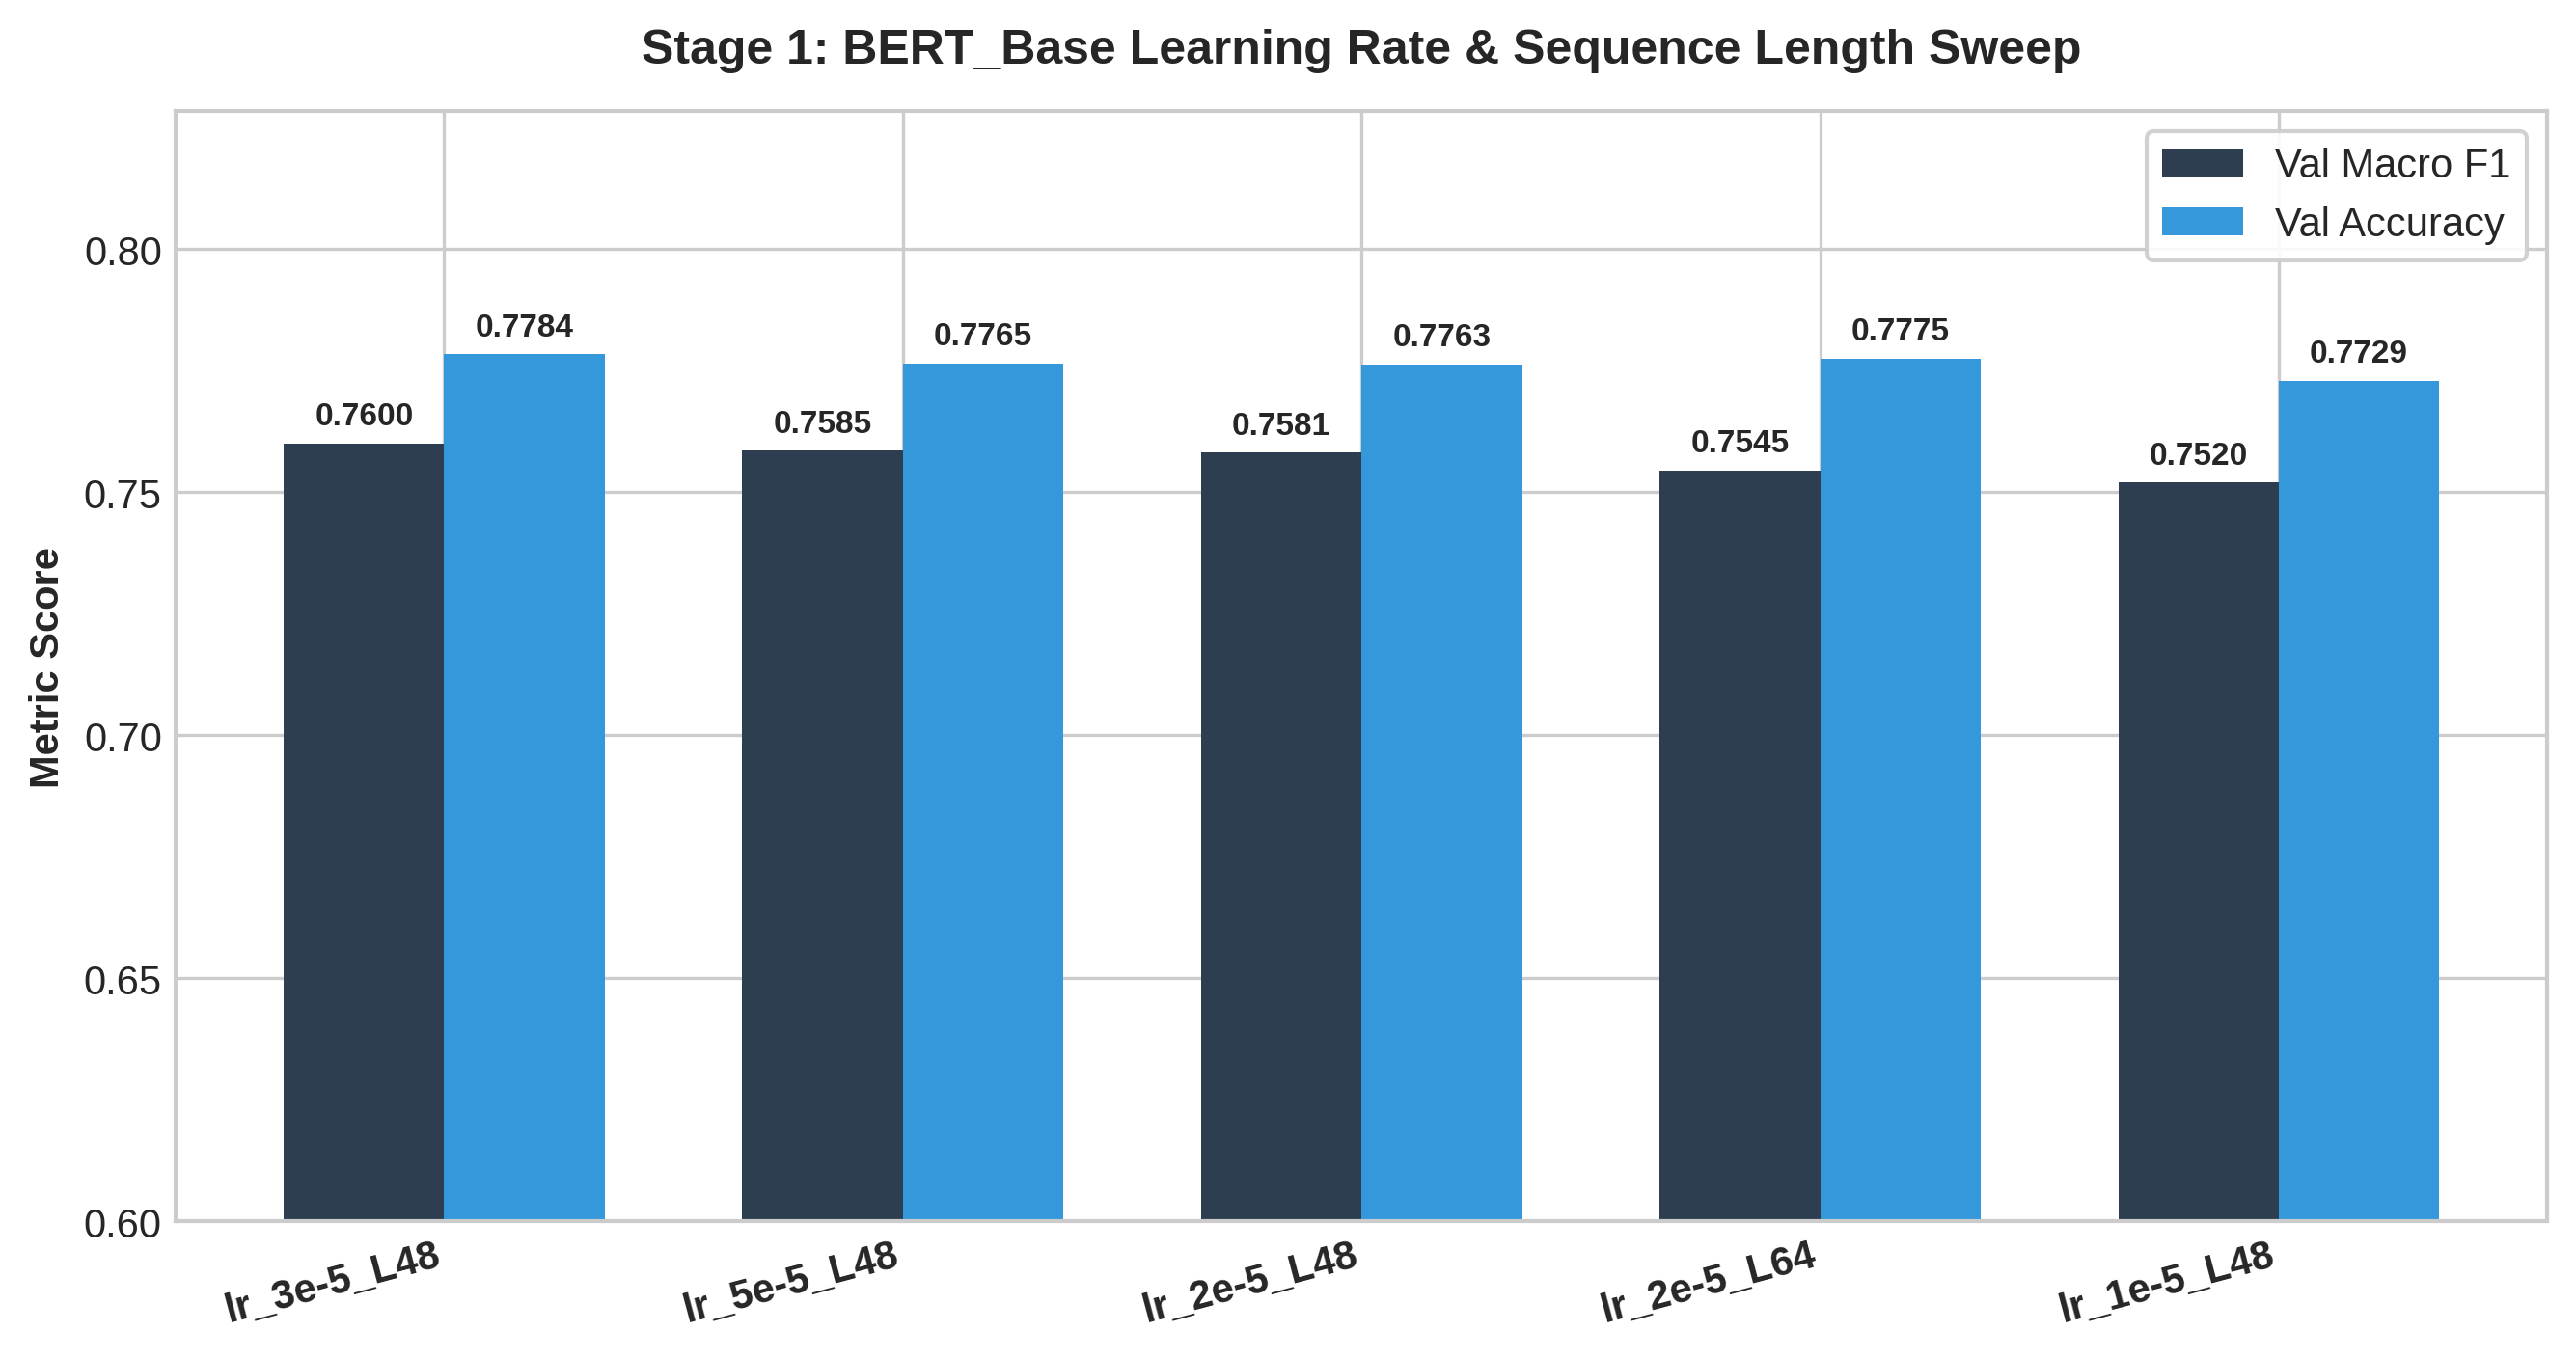

In [6]:
# Plot Hyperparameter Sweep
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=300)

x = np.arange(len(df_tune))
w = 0.35

r1 = ax.bar(x - w/2, df_tune["Val_Macro_F1"], w, label="Val Macro F1", color="#2c3e50")
r2 = ax.bar(x + w/2, df_tune["Val_Accuracy"], w, label="Val Accuracy", color="#3498db")

ax.set_title(f"Stage 1: BERT_Base Learning Rate & Sequence Length Sweep", fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel("Metric Score", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_tune["Config"], rotation=15, ha='right', fontweight='bold')
ax.set_ylim(0.60, max(df_tune["Val_Accuracy"].max(), df_tune["Val_Macro_F1"].max()) + 0.05)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)

for rect in r1:
    h = rect.get_height()
    ax.annotate(f"{h:.4f}", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')
for rect in r2:
    h = rect.get_height()
    ax.annotate(f"{h:.4f}", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(TUNING_DIR, "lr_hyperparam_tuning_curve.png"), dpi=300)
plt.show()


## Stage 2: Full Fine-Tuning of Optimal BERT_Base Model

Fine-tuning `bert-base-uncased` for 3 full epochs using optimal parameters ($\eta^* = $ `BEST_LR`, $L^* = $ `BEST_MAX_LEN`) with linear warmup and cosine decay scheduler.


In [7]:
# Final Fine-Tuning Execution
print("="*75)
print(f"STAGE 2: Full Fine-Tuning of BERT_Base (LR={BEST_LR}, MaxLen={BEST_MAX_LEN}, 3 Epochs)")
print("="*75)

train_loader, val_loader, test_loader = get_dataloaders(max_len=BEST_MAX_LEN, batch_size=32)

set_seed(42)
final_model = AutoModelForSequenceClassification.from_pretrained(MODEL_HF_NAME, num_labels=num_classes)
final_model.to(device)

optimizer = torch.optim.AdamW(final_model.parameters(), lr=BEST_LR, weight_decay=0.01)
epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * 0.1), num_training_steps=total_steps)

best_val_f1 = 0.0
best_state = None
history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

for epoch in range(1, epochs + 1):
    t_ep = time.time()
    final_model.train()
    total_train_loss = 0.0
    train_preds, train_targets = [], []
    
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        if scaler:
            with torch.cuda.amp.autocast():
                outputs = final_model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = final_model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
            optimizer.step()
            
        scheduler.step()
        total_train_loss += loss.item() * len(labels)
        train_preds.extend(torch.argmax(outputs.logits, dim=1).detach().cpu().numpy())
        train_targets.extend(labels.detach().cpu().numpy())
        
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    _, _, train_f1, _ = precision_recall_fscore_support(train_targets, train_preds, average='macro', zero_division=0)
    
    # Validation
    final_model.eval()
    total_val_loss = 0.0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = final_model(input_ids, attention_mask=attention_mask, labels=labels)
            else:
                outputs = final_model(input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item() * len(labels)
            val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_targets, val_preds)
    _, _, val_f1, _ = precision_recall_fscore_support(val_targets, val_preds, average='macro', zero_division=0)
    
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    
    print(f"Epoch {epoch}/{epochs} ({time.time()-t_ep:.1f}s) | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in final_model.state_dict().items()}

if best_state is not None:
    final_model.load_state_dict(best_state)

# Save best model checkpoint
torch.save(final_model.state_dict(), os.path.join(MODEL_DIR, "best_model.pt"))
print(f"\nSaved best model checkpoint to {os.path.join(MODEL_DIR, 'best_model.pt')}")


STAGE 2: Full Fine-Tuning of BERT_Base (LR=3e-05, MaxLen=48, 3 Epochs)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_23/4292635916.py:34: F

Epoch 1/3 (189.7s) | Train Loss: 0.9239 | Val Loss: 0.6599 | Val Macro F1: 0.7476 | Val Acc: 0.7686


/tmp/ipykernel_23/4292635916.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_23/4292635916.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/3 (190.3s) | Train Loss: 0.5418 | Val Loss: 0.6445 | Val Macro F1: 0.7432 | Val Acc: 0.7715


/tmp/ipykernel_23/4292635916.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_23/4292635916.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 3/3 (190.8s) | Train Loss: 0.3876 | Val Loss: 0.6786 | Val Macro F1: 0.7507 | Val Acc: 0.7731

Saved best model checkpoint to /kaggle/working/results/05_transformer_bert/models/bert_base/best_model.pt


/tmp/ipykernel_23/1267820221.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



FINAL TEST EVALUATION: BERT_Base
  Test Accuracy:     0.7792
  Test Macro F1:     0.7586
  Test Weighted F1:  0.7753
  Test Precision:    0.7628
  Test Recall:       0.7567
  Inference Latency: 0.727 ms/tweet


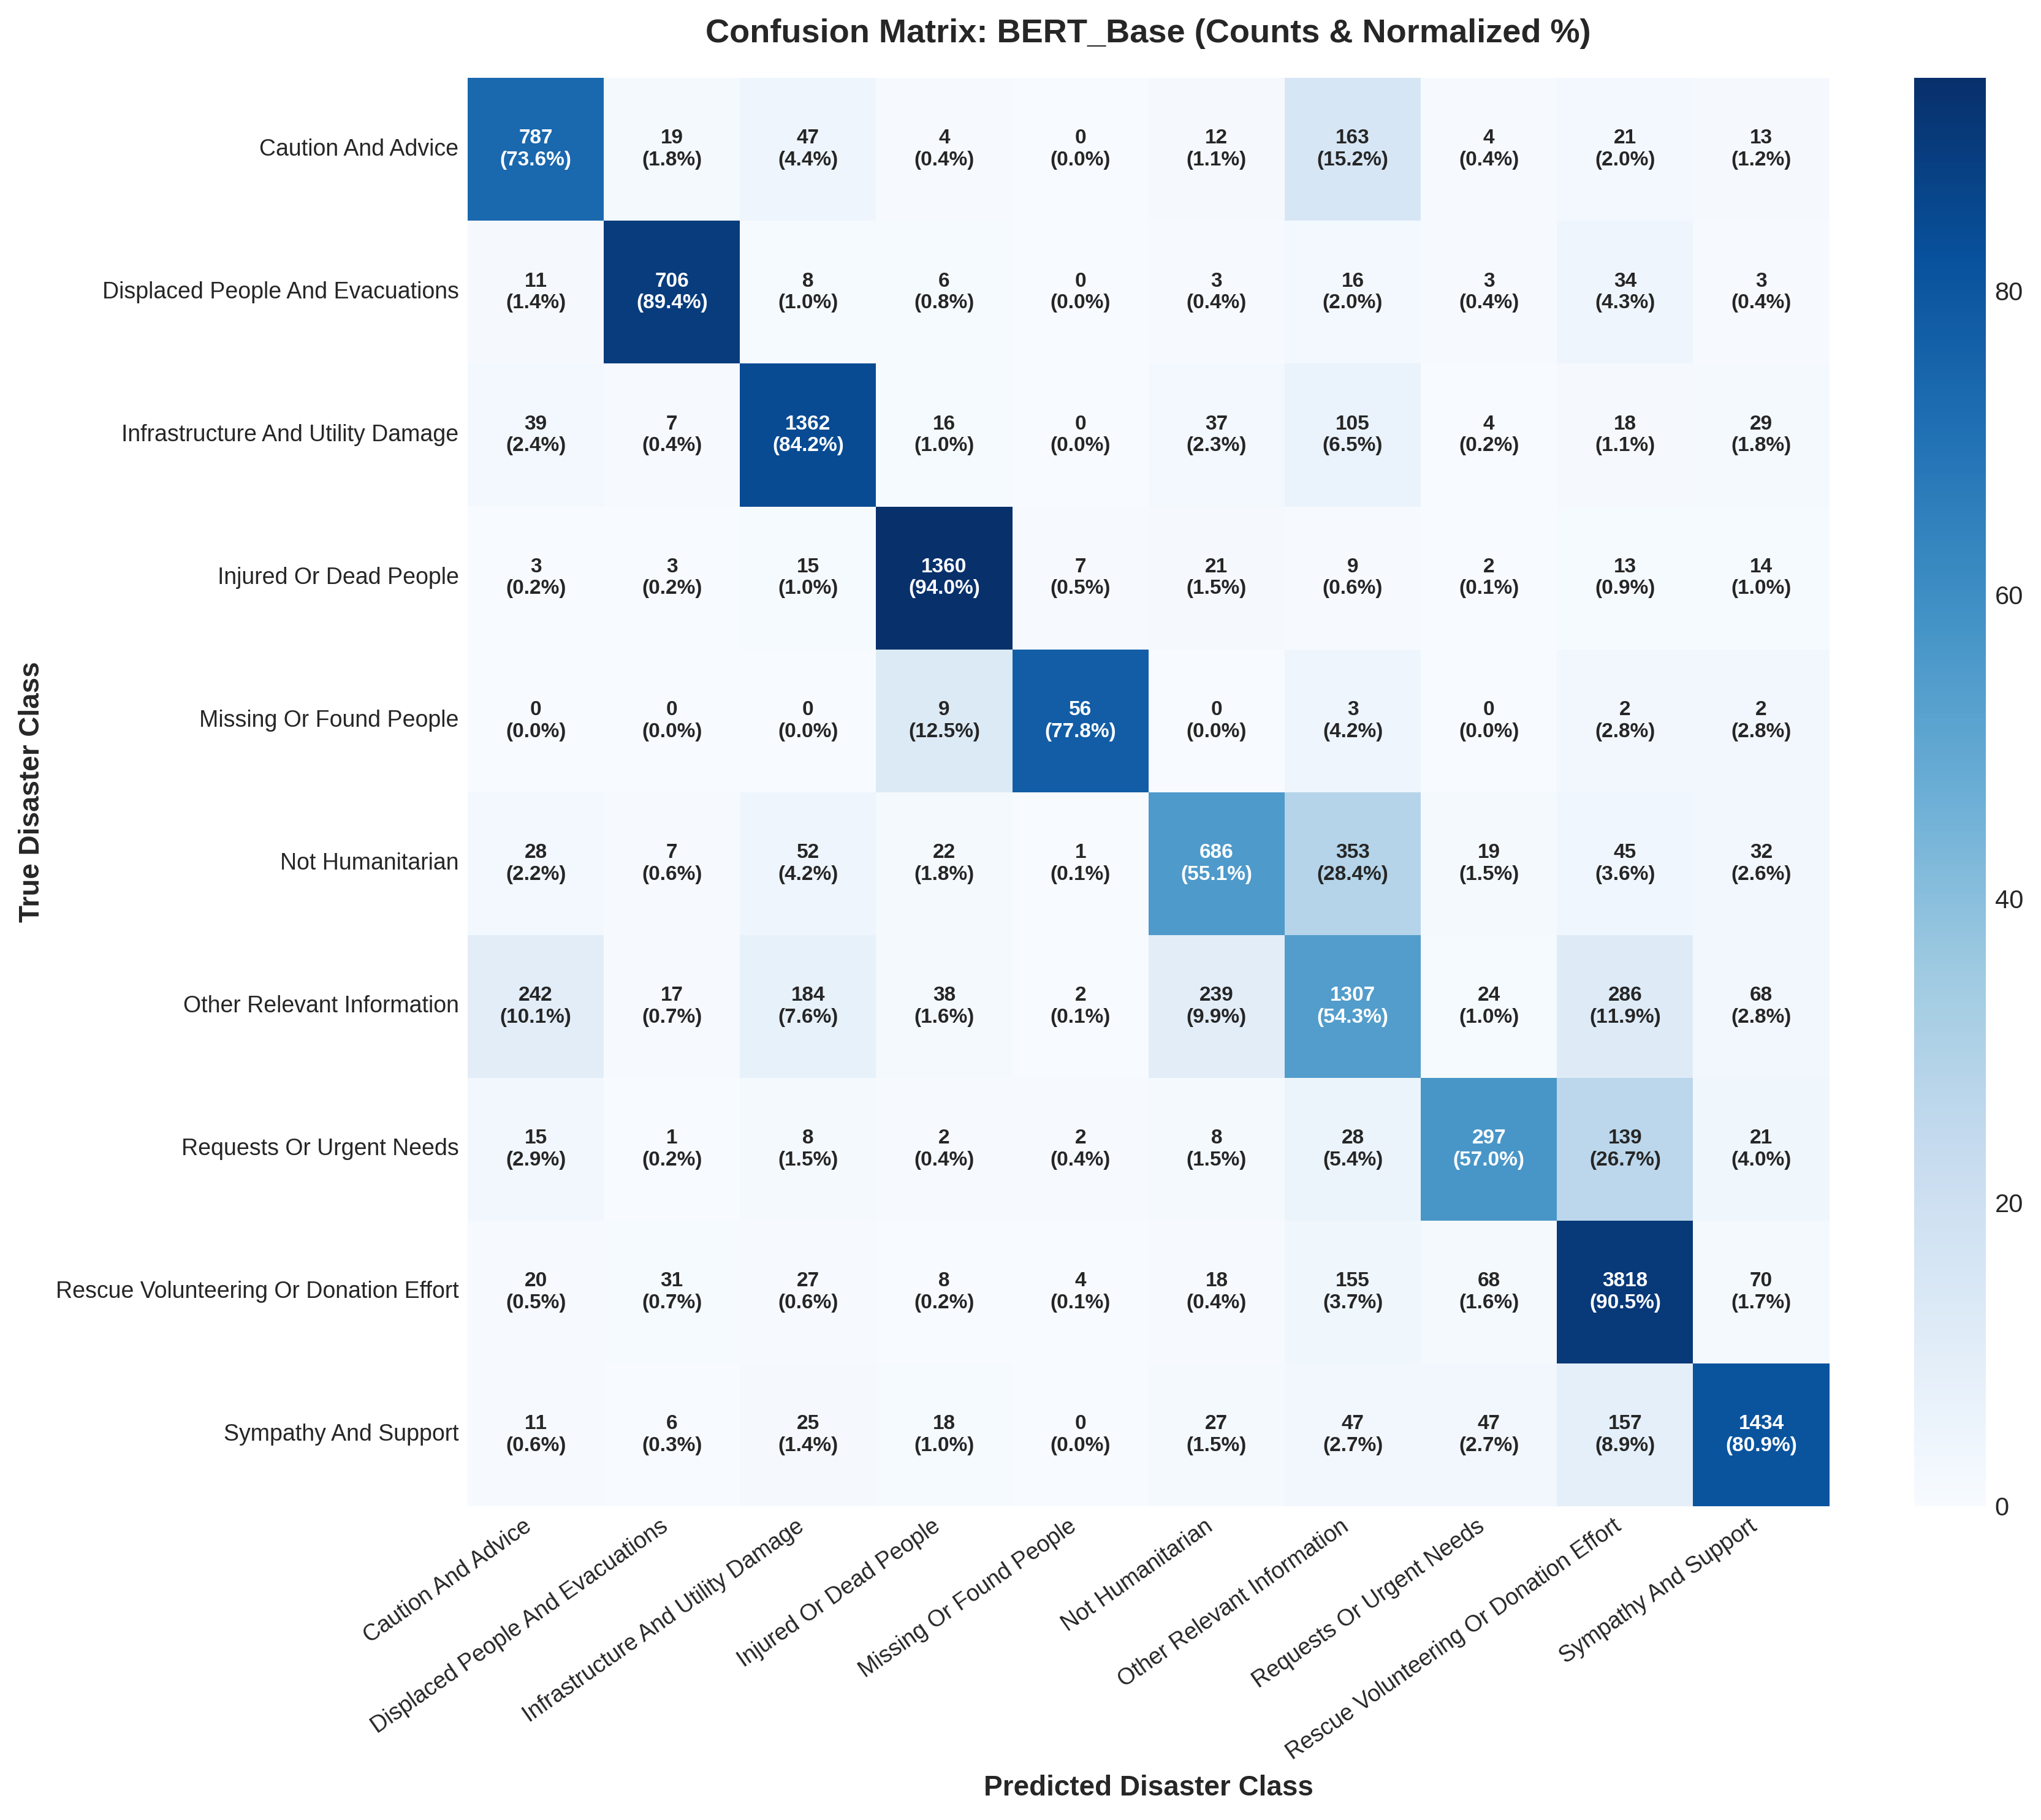

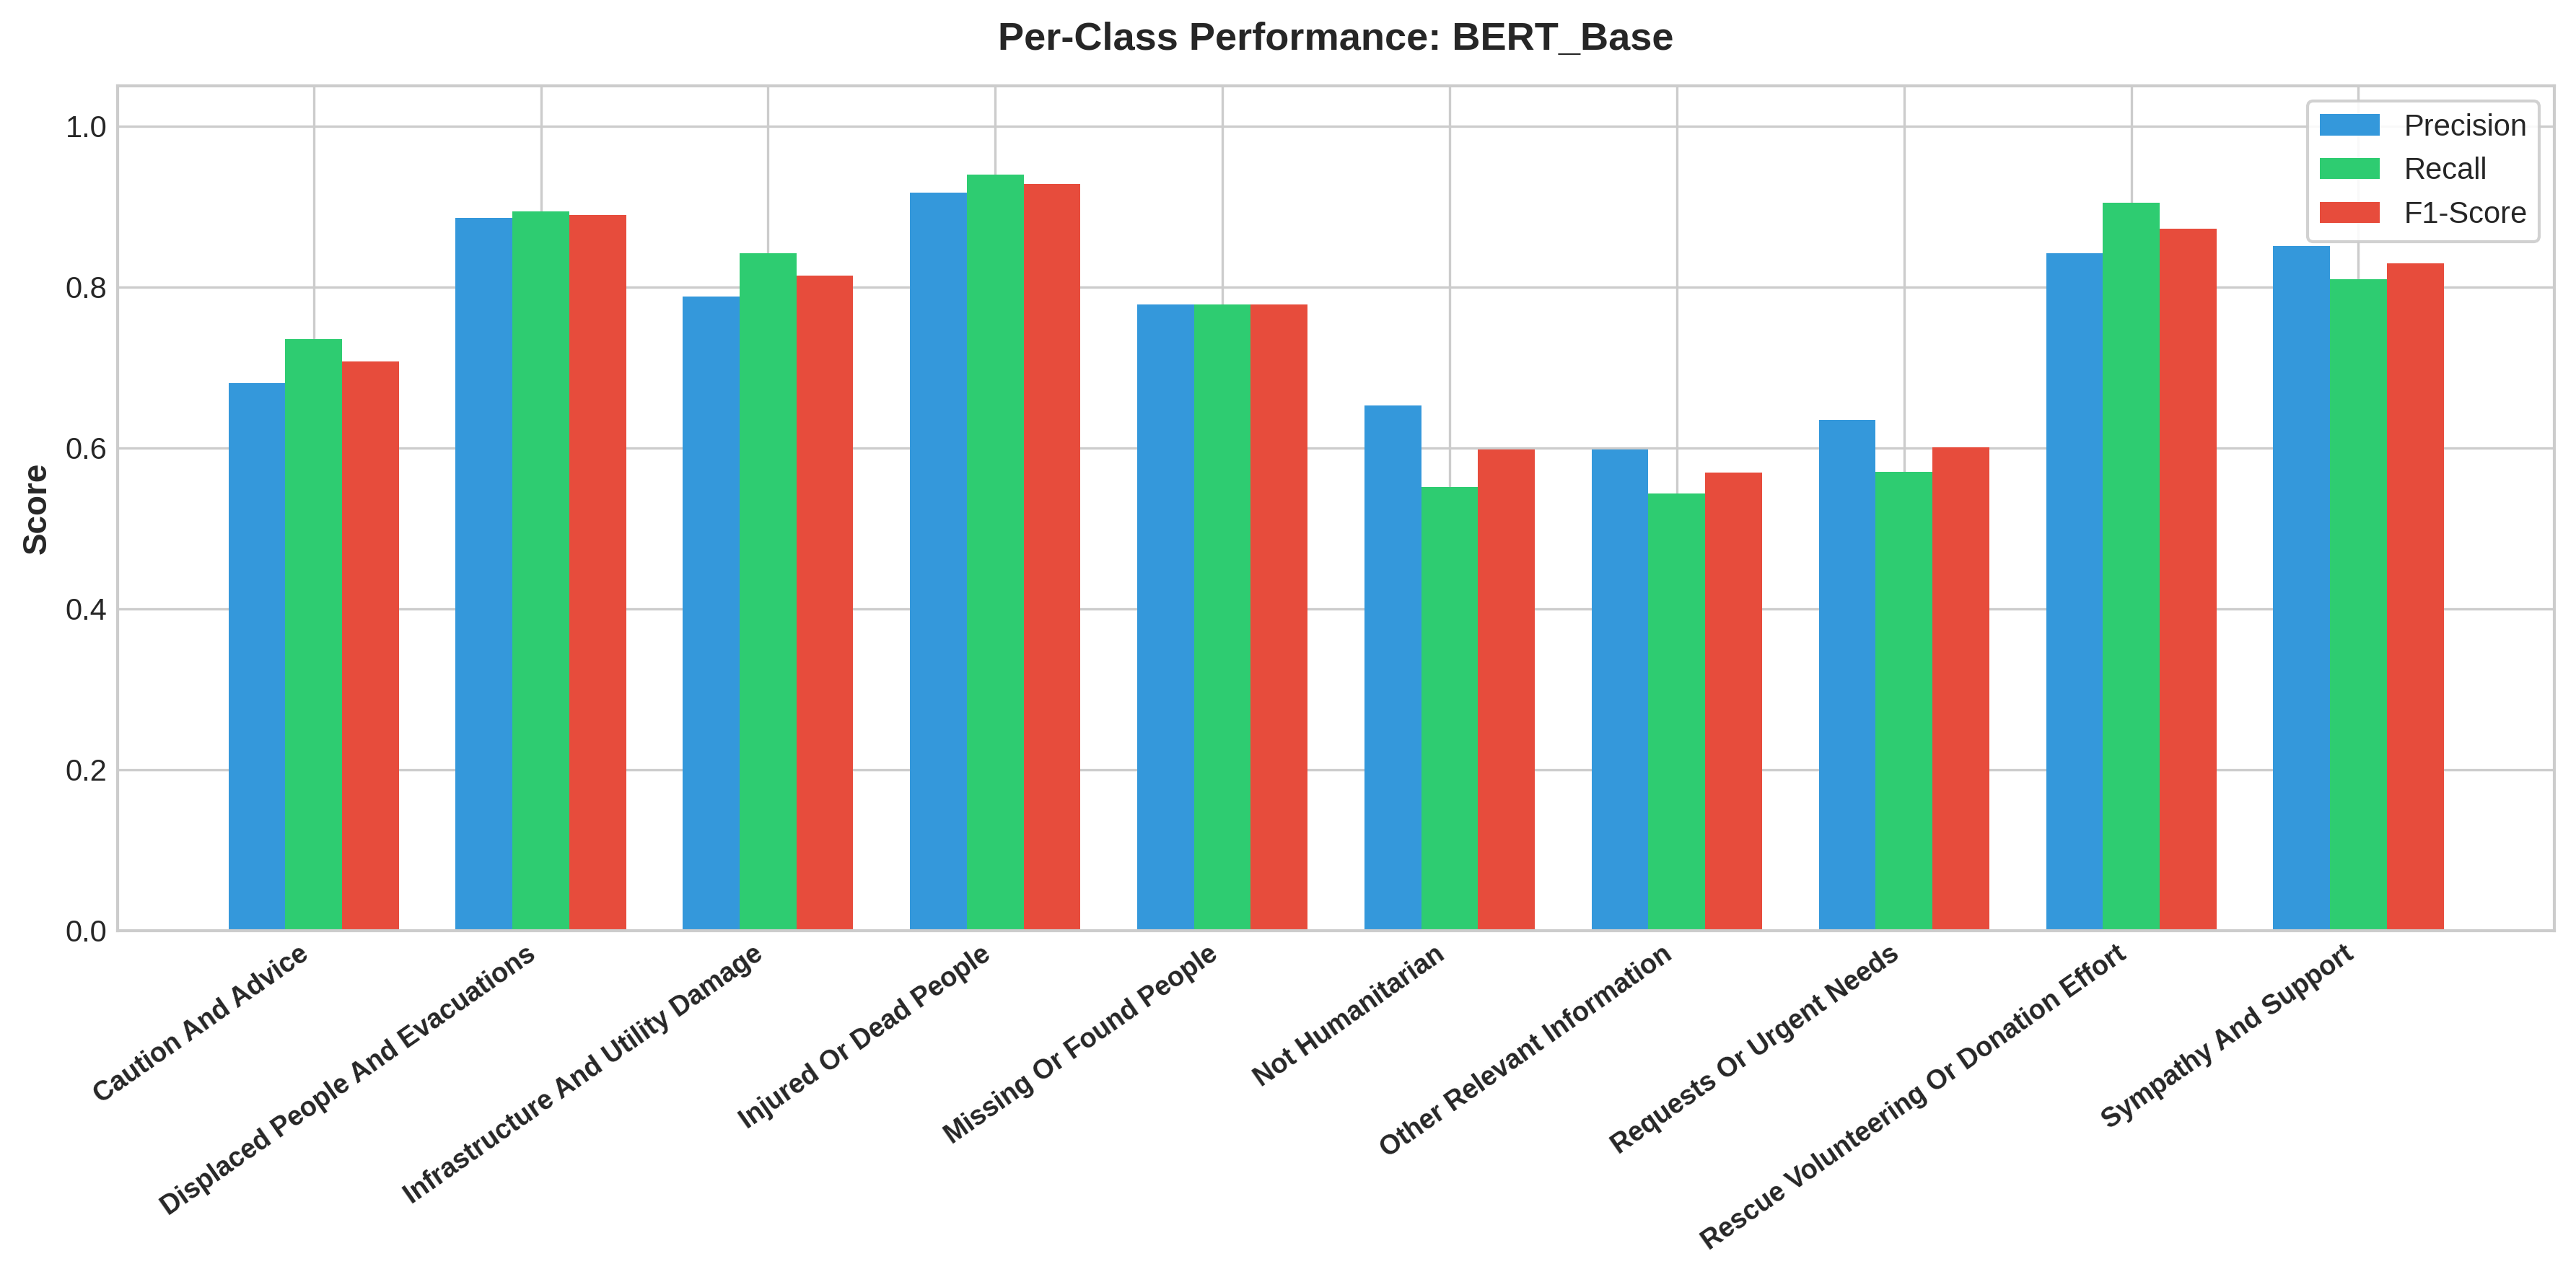

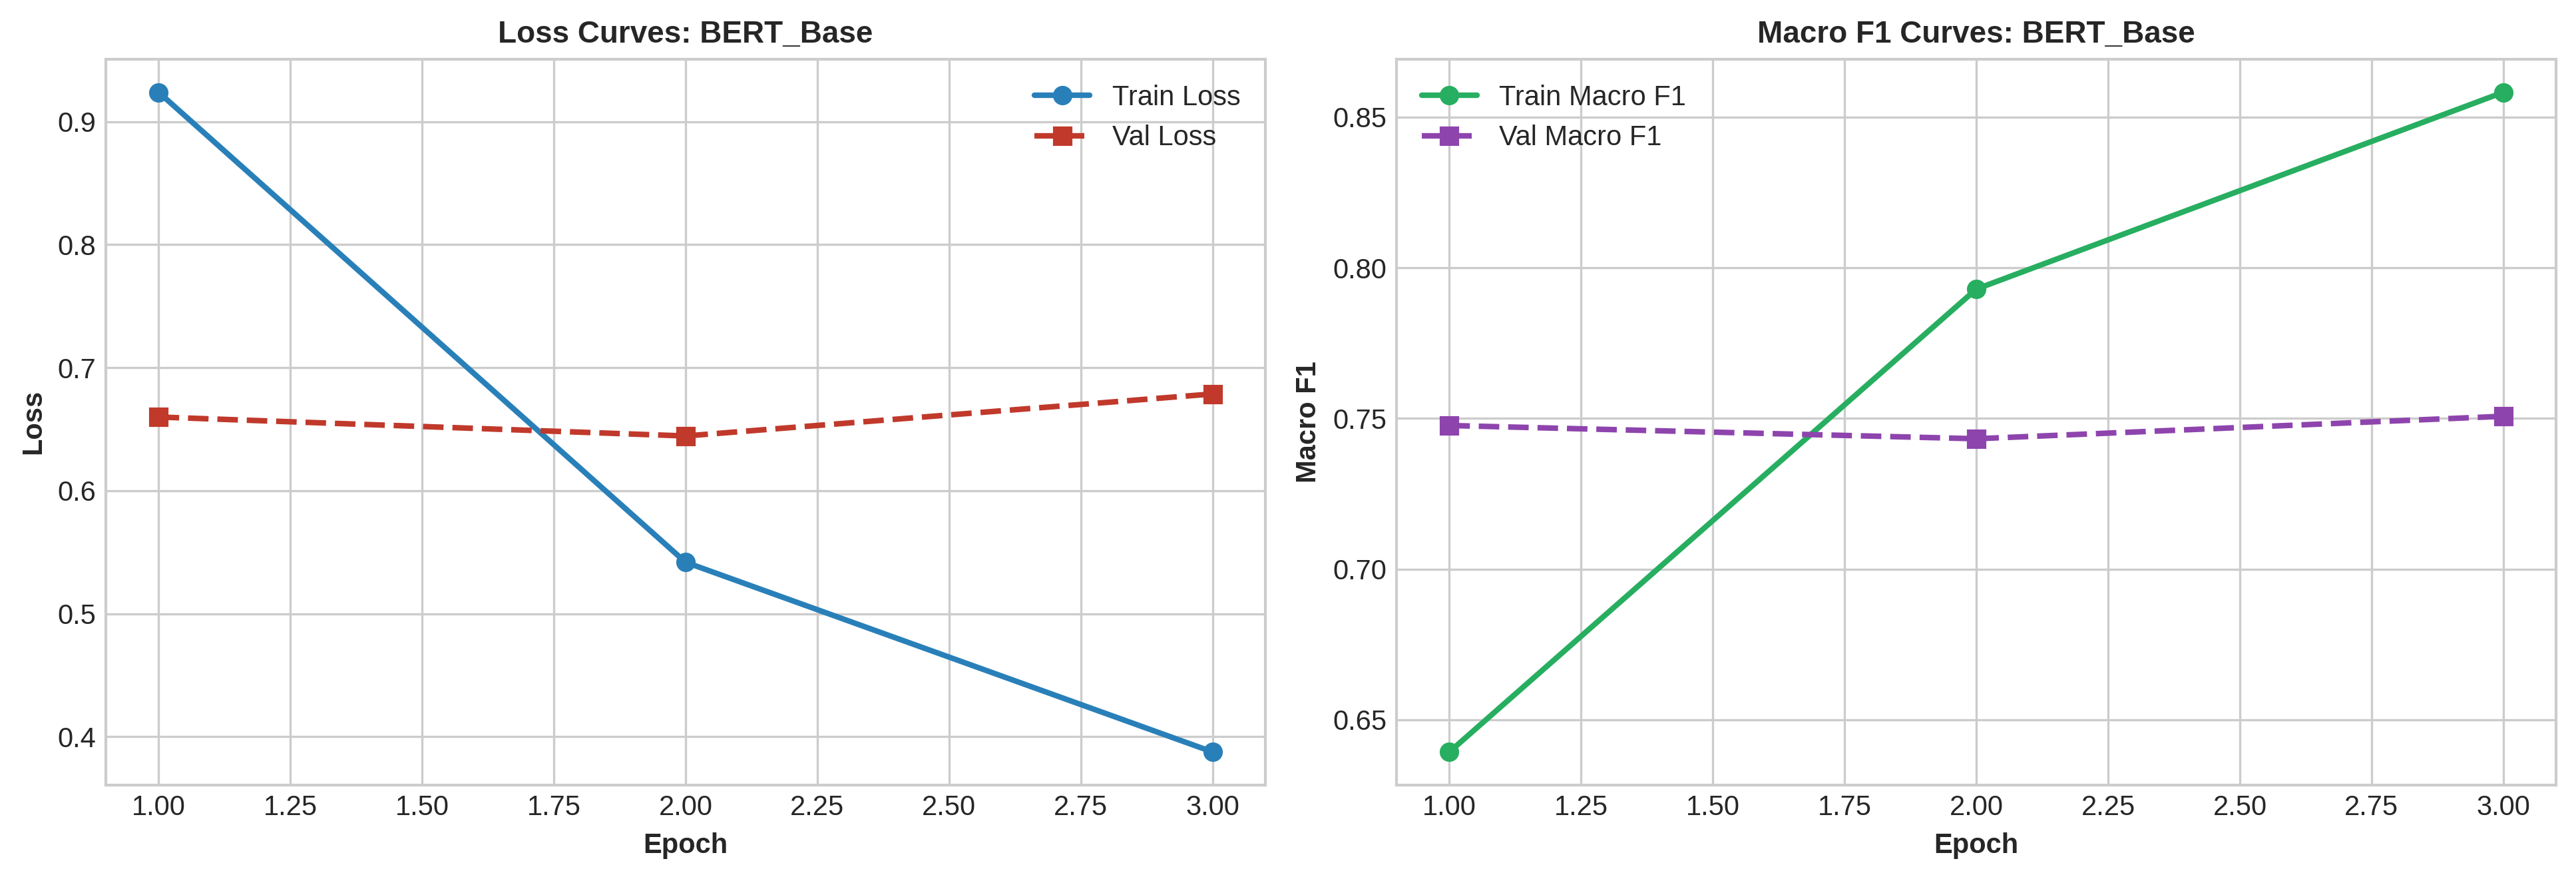

In [8]:
# Test Set Evaluation
final_model.eval()
final_model.to(device)
test_preds = []
t0 = time.time()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        if scaler:
            with torch.cuda.amp.autocast():
                logits = final_model(input_ids, attention_mask=attention_mask).logits
        else:
            logits = final_model(input_ids, attention_mask=attention_mask).logits
        test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

latency_ms = ((time.time() - t0) / len(y_test)) * 1000.0
test_preds = np.array(test_preds)

acc = accuracy_score(y_test, test_preds)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, test_preds, average='macro', zero_division=0)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, test_preds, average='weighted', zero_division=0)

print("\n" + "="*75)
print(f"FINAL TEST EVALUATION: BERT_Base")
print("="*75)
print(f"  Test Accuracy:     {acc:.4f}")
print(f"  Test Macro F1:     {f1_macro:.4f}")
print(f"  Test Weighted F1:  {f1_weighted:.4f}")
print(f"  Test Precision:    {p_macro:.4f}")
print(f"  Test Recall:       {r_macro:.4f}")
print(f"  Inference Latency: {latency_ms:.3f} ms/tweet")

# Classification Report
cls_dict = classification_report(y_test, test_preds, target_names=formatted_class_names, output_dict=True, zero_division=0)
df_cls = pd.DataFrame(cls_dict).transpose()
df_cls.to_csv(os.path.join(MODEL_DIR, "classification_report.csv"))

with open(os.path.join(MODEL_DIR, "classification_report.txt"), "w") as f:
    f.write(classification_report(y_test, test_preds, target_names=formatted_class_names, digits=4, zero_division=0))

# Dual Confusion Matrix (Raw Count + Normalized %)
cm_raw = confusion_matrix(y_test, test_preds)
cm_norm = confusion_matrix(y_test, test_preds, normalize='true') * 100.0
annot_matrix = np.empty_like(cm_raw, dtype=object)
for i in range(num_classes):
    for j in range(num_classes):
        annot_matrix[i, j] = f"{cm_raw[i, j]}\n({cm_norm[i, j]:.1f}%)"

plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(cm_norm, annot=annot_matrix, fmt="", cmap="Blues", cbar=True,
            xticklabels=formatted_class_names, yticklabels=formatted_class_names,
            annot_kws={"size": 8, "fontweight": "bold"})
plt.title(f"Confusion Matrix: BERT_Base (Counts & Normalized %)", fontsize=13, fontweight='bold', pad=14)
plt.xlabel("Predicted Disaster Class", fontsize=11, fontweight='bold')
plt.ylabel("True Disaster Class", fontsize=11, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

# Per-Class Metrics Bar Chart
per_class_f1 = [cls_dict[c]["f1-score"] for c in formatted_class_names]
per_class_rec = [cls_dict[c]["recall"] for c in formatted_class_names]
per_class_prec = [cls_dict[c]["precision"] for c in formatted_class_names]

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
x = np.arange(num_classes)
w = 0.25
ax.bar(x - w, per_class_prec, w, label="Precision", color="#3498db")
ax.bar(x, per_class_rec, w, label="Recall", color="#2ecc71")
ax.bar(x + w, per_class_f1, w, label="F1-Score", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(formatted_class_names, rotation=35, ha='right', fontsize=9, fontweight='bold')
ax.set_ylabel("Score", fontsize=11, fontweight='bold')
ax.set_title(f"Per-Class Performance: BERT_Base", fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 1.05)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "per_class_metrics.png"), dpi=300)
plt.show()

# Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=300)
epochs_range = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_range, history["train_loss"], 'o-', label="Train Loss", color="#2980b9", lw=2)
ax1.plot(epochs_range, history["val_loss"], 's--', label="Val Loss", color="#c0392b", lw=2)
ax1.set_title(f"Loss Curves: BERT_Base", fontsize=11, fontweight='bold')
ax1.set_xlabel("Epoch", fontweight='bold')
ax1.set_ylabel("Loss", fontweight='bold')
ax1.legend()

ax2.plot(epochs_range, history["train_f1"], 'o-', label="Train Macro F1", color="#27ae60", lw=2)
ax2.plot(epochs_range, history["val_f1"], 's--', label="Val Macro F1", color="#8e44ad", lw=2)
ax2.set_title(f"Macro F1 Curves: BERT_Base", fontsize=11, fontweight='bold')
ax2.set_xlabel("Epoch", fontweight='bold')
ax2.set_ylabel("Macro F1", fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "training_curves.png"), dpi=300)
plt.show()

# Save final test metrics summary
metrics_summary = [{
    "Model": f"BERT_Base",
    "Optimal_LR": BEST_LR,
    "Optimal_Max_Len": BEST_MAX_LEN,
    "Accuracy": round(acc, 4),
    "Macro_F1": round(f1_macro, 4),
    "Weighted_F1": round(f1_weighted, 4),
    "Precision": round(p_macro, 4),
    "Recall": round(r_macro, 4),
    "Latency_ms": round(latency_ms, 3)
}]
pd.DataFrame(metrics_summary).to_csv(os.path.join(MODEL_DIR, "metrics.csv"), index=False)


In [9]:
# Package all results into zip file
import shutil
zip_path = "results_05_transformer_bert"
shutil.make_archive(zip_path, 'zip', OUTPUT_BASE)
print(f"\nAll artifacts successfully packaged to {zip_path}.zip!")
print(f"Execution complete. Output directory: {OUTPUT_BASE}")



All artifacts successfully packaged to results_05_transformer_bert.zip!
Execution complete. Output directory: /kaggle/working/results/05_transformer_bert
